In [5]:
import lfadsci
import lfadsci.run_utils

import importlib

import lfadsci.shared_utils
importlib.reload(lfadsci.shared_utils)
import lfadsci.shared_utils


import lfadsci.model
import yaml
import numpy as np

import sklearn
convert_to_2d = lambda x: np.reshape(x, [-1, x.shape[-1]])

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt


import lfadsci.utils_pendulum
importlib.reload(lfadsci.utils_pendulum)


import os

import pickle

# get data

In [10]:
config = yaml.load(open('/oak/stanford/groups/henderj/nishalps/code/lfads_ci/src/lfadsci/configs/dataset/pendulum.yaml'),
                   Loader=yaml.FullLoader)

data_seeds = {}
for seed in [98]: #,99,100,101,102,103,104,105,106,107]:

    data = lfadsci.run_utils.get_data({'dataset': config, 
                                       'batch_size': 512, 
                                       'train_frac': 0.6, 'val_frac': 0.2, 
                                       'test_frac': 0.2, 'data_seed': seed})
    data_seeds.update({seed: data})
    
n_channels = [dataset['train']['neural'].shape[-1] for dataset in data['datasets']]


getting pendulum data
..................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [7]:
np.arange(0.5, 4.5, 0.5).shape

(8,)

In [22]:
len(data['datasets'][0]['train']['neural']) / 8

75.0

In [23]:
len(data['datasets'][0]['test']['neural']) / 8

25.125

In [24]:
len(data['datasets'][0]['eval']['neural']) / 8

25.0

In [18]:
data['datasets'][0]['train']['neural'][0].shape

(300, 192)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

<Figure size 432x288 with 0 Axes>

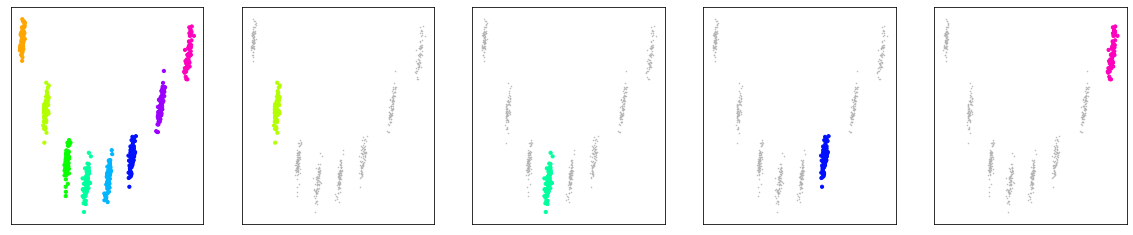

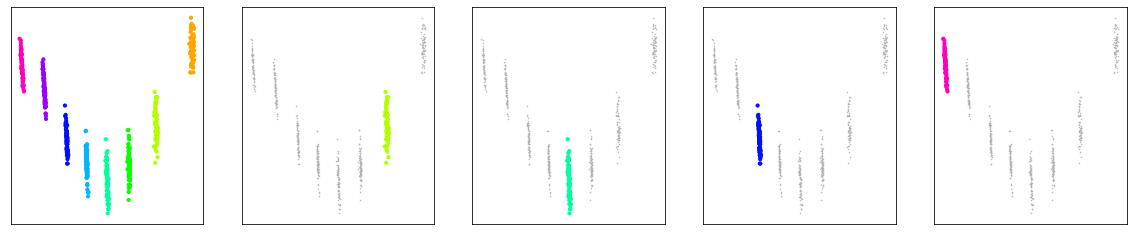

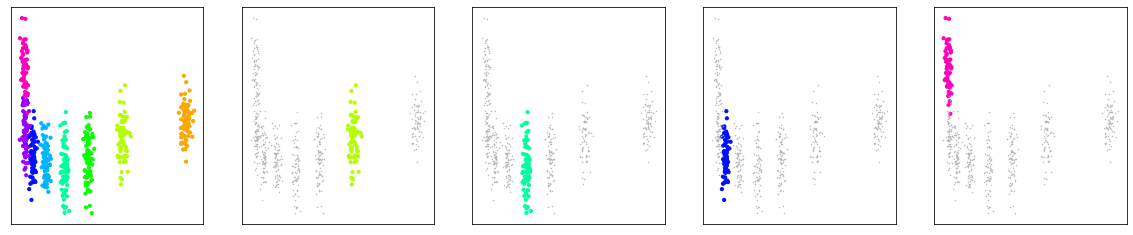

In [3]:

model_dir = '/scratch/users/nishalps/seq_models/pendulum/'
partition_use = 'train'


for seed_use in data_seeds.keys():
    bias_use = True

    model_str = f'dataset=pendulum,model.bias_dim=5,model.dropout_rate=0.0,model.generator_type=gru,model.ic_dim=5,model.lam_l2=0,model.n_hidden_decode=200,model.noise_stddev=0.0,model.tv_input_dim=1,model.use_bias={bias_use},model.use_tv_input=False,seed=98'

    results = pickle.load(open(os.path.join(model_dir, model_str + '/results_full.pkl'), 'rb'))
    results = results['results_list'][0]
    
    datasets = data_seeds[seed_use]['datasets'][0]
    cues = [float(c.split(',')[1]) for c in datasets[partition_use]['cues']]
    
    
    plt.suptitle(f'seed: {seed_use}')
    
    for ifeature, feature_name in enumerate(['fixed_points', 'bias_sample', 'ic_sample']):
        plt.figure(figsize=(20, 4))
        if feature_name in results[partition_use].keys():
                

            if feature_name == 'fixed_points':
                datasets[partition_use].update({'g_use': cues})
                feature, _, trial_ids_, speeds_ = lfadsci.shared_utils.select_fixedpoints(results[partition_use], 
                                                                     datasets[partition_use], cues_key='g_use')

                cues_sel = speeds_ < 1e-7
                cues_use = np.array(cues)[cues_sel, ...]
                feature = feature[cues_sel, ...]
            else:
                feature = results[partition_use][feature_name]
                cues_use = np.array(cues)
            
#             {0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0}
            for iidx, idx_plot in enumerate([None, 
                                             np.where(1.0 == cues_use)[0],
                                             np.where(2.0 == cues_use)[0],
                                             np.where(3.0 == cues_use)[0],
                                             np.where(4.0 == cues_use)[0],
                                            ]):
                                             
                
                plt.subplot(1, 5, iidx + 1)
            
                lfadsci.utils_pendulum.analysis_single_pts_pendulum(feature, cues_use, 
                                                              markersize=10, 
                                                              method='pca', new_fig=False, 
                                                              idx_plot=idx_plot)
                
                if idx_plot is None:
                    xlim = plt.gca().get_xlim()
                    ylim = plt.gca().get_ylim()
                else:
                    plt.gca().set_xlim(xlim)
                    plt.gca().set_ylim(ylim)
                    
                plt.xticks([])
                plt.yticks([])

#                 plt.savefig(f'/oak/stanford/groups/henderj/nishalps/code/lfads_ci/docs/mc_maze/{feature_name}_{seed_use}.pdf')
                
#                 u, i = np.unique(datasets[partition_use]['cues'], return_inverse=True)
#                 accuracy_mean, accuracy_sd = get_classification_accuracy(feature, i) 
#                 plt.title(f'{key}: color by cue, accuracy: %.2f +/- %.2f' % (accuracy_mean, accuracy_sd))
                
    
    

In [10]:
set([float(c.split(',')[1]) for c in datasets[partition_use]['cues']])

{0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0}

In [ ]:
cues

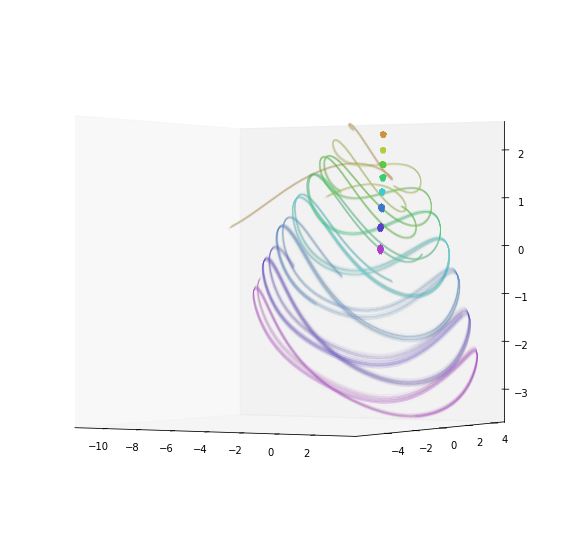

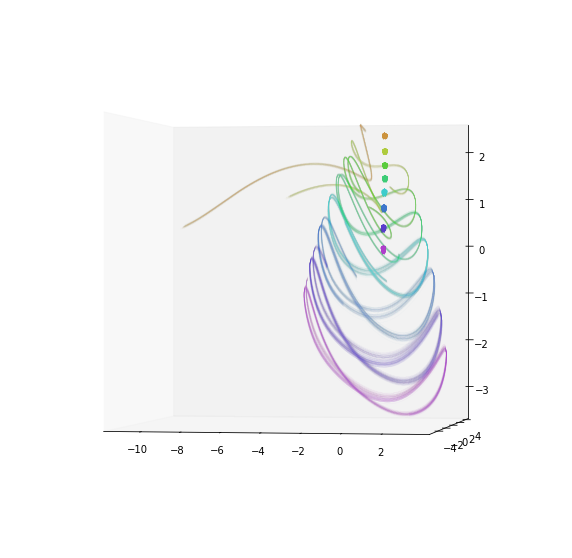

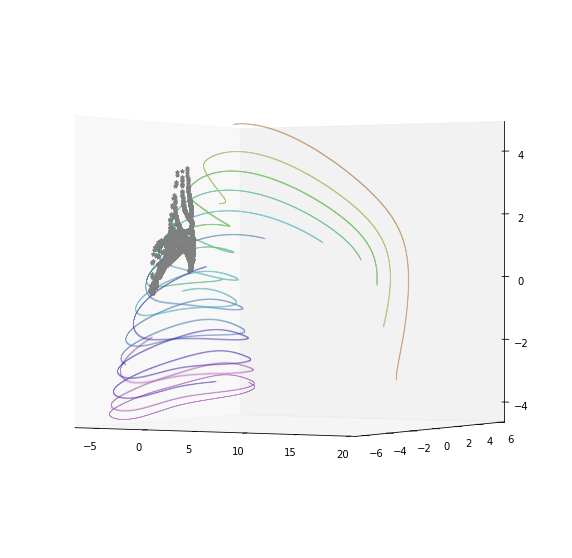

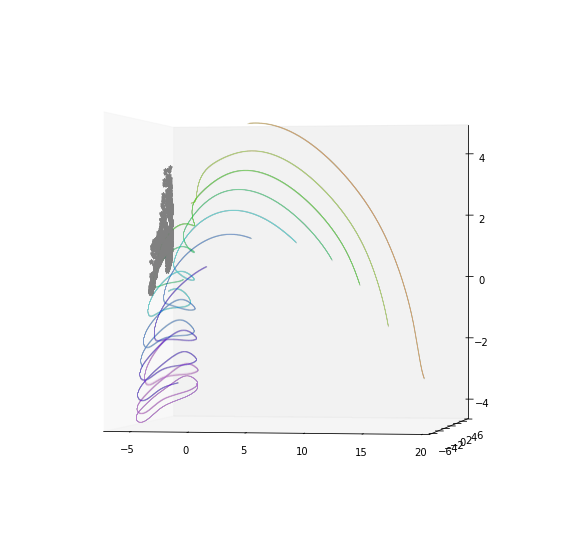

In [4]:

model_dir = '/scratch/users/nishalps/seq_models/pendulum/'
partition_use = 'train'

for seed_use in [98]: #data_seeds.keys():
    
    for bias_use in [True, False]:
        model_str = f'dataset=pendulum,model.bias_dim=5,model.dropout_rate=0.0,model.generator_type=gru,model.ic_dim=5,model.lam_l2=0,model.n_hidden_decode=200,model.noise_stddev=0.0,model.tv_input_dim=1,model.use_bias={bias_use},model.use_tv_input=False,seed=98'

        results = pickle.load(open(os.path.join(model_dir, model_str + '/results_full.pkl'), 'rb'))
        results = results['results_list'][0]

        datasets = data_seeds[seed_use]['datasets'][0]
        
        cues = [float(c.split(',')[1]) for c in datasets[partition_use]['cues']]
        
        for azim in [-60, -80]:
            lfadsci.utils_pendulum.plot_states_fps(cues, 
                            results['train']['state'][:, 100:, :], 
                            results['train']['fixed_points_filtered'], 
                            n_comps_cis=2, 
                            elev=0, azim=azim, alpha_state=1, alpha_fp=1, 
                            color_fixedpoints=bias_use, 
                            fp_marker='*', fp_markersize=4, state_lw=0.01, 
                            add_cis_dimension=True)

            plt.savefig(f'/oak/stanford/groups/henderj/nishalps/code/lfads_ci/docs/pendulum/states_fps_{seed_use}_bias_{bias_use}_azim_{azim}.pdf')
            plt.show()


# Eigen value analysis

In [ ]:
# bias model

In [13]:
model_dir = '/scratch/users/nishalps/seq_models/pendulum/'
partition_use = 'train'


bias_use  = True
model_str = f'dataset=pendulum,model.bias_dim=5,model.dropout_rate=0.0,model.generator_type=gru,model.ic_dim=5,model.lam_l2=0,model.n_hidden_decode=200,model.noise_stddev=0.0,model.tv_input_dim=1,model.use_bias={bias_use},model.use_tv_input=False,seed=98'

print('Get results')
results = pickle.load(open(os.path.join(model_dir, model_str + '/results_full.pkl'), 'rb'))
results = results['results_list'][0]

datasets = data_seeds[seed_use]['datasets'][0]
cues = [float(c.split(',')[1]) for c in datasets[partition_use]['cues']]
n_channels = [dataset['train']['neural'].shape[-1] for dataset in data_seeds[seed_use]['datasets']]
    
print('Get model')
import yaml
model_config = yaml.load(open(os.path.join(model_dir, model_str + '/.hydra/config.yaml')),
                       Loader=yaml.FullLoader)

model = lfadsci.model.load_model_from_config(model_config, 
                       n_channels, 
                       model_filename=os.path.join(model_dir, model_str + '/model'), 
                      #suffix='-iter=5000'
                                            )
            

results = lfadsci.shared_utils.complete_fixed_point_analysis(model, results, EPS1=1e-7, 
                                        get_fixed_points_only=False, 
                                        partition='train', to_plot=False, session_id=0)

Get results
Get model
Building initial condition encoder
Building bias encoder
mu_phi (None, 5) sig_phi (None, 5)
Model loaded


100%|██████████| 60000/60000 [06:03<00:00, 164.84it/s]


fixed point finding time: 364.01942586898804
    Kept 18/20 fixed points with tolerance under 0.000000.
    Kept 14/20 fixed points with tolerance under 0.000000.
    Kept 15/20 fixed points with tolerance under 0.000000.
    Kept 10/20 fixed points with tolerance under 0.000000.
    Kept 14/20 fixed points with tolerance under 0.000000.
    Kept 18/20 fixed points with tolerance under 0.000000.
    Kept 10/20 fixed points with tolerance under 0.000000.
    Kept 18/20 fixed points with tolerance under 0.000000.
    Kept 16/20 fixed points with tolerance under 0.000000.
    Kept 17/20 fixed points with tolerance under 0.000000.
    Kept 9/20 fixed points with tolerance under 0.000000.
    Kept 18/20 fixed points with tolerance under 0.000000.
    Kept 18/20 fixed points with tolerance under 0.000000.
    Kept 18/20 fixed points with tolerance under 0.000000.
    Kept 11/20 fixed points with tolerance under 0.000000.
    Kept 12/20 fixed points with tolerance under 0.000000.
    Kept 14/

    Kept 1/16 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/17 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/12 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/18 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/18 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/16 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/20 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/18 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/10 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/14 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/15 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/17 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/12 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/15 unique fixed points with uniqueness tolerance 0.100000.
    Kept 1/7 unique 

100%|██████████| 600/600 [08:49<00:00,  1.13it/s]


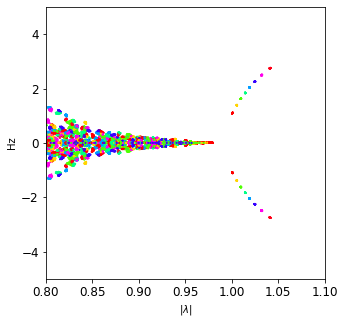

In [17]:
plt.figure(figsize=(5, 5))
ax = plt.gca()
lfadsci.utils_pendulum.ev_plot_pendulum(data['datasets'][0], 
                                 results, 
                                 sz_scale=1, ax=ax)

ax.set_xlim([0.8, 1.1])
ax.set_ylim([-5, 5])
    
plt.savefig('/oak/stanford/groups/henderj/nishalps/code/lfads_ci/docs/pendulum/evals_all.pdf')
plt.savefig('/oak/stanford/groups/henderj/nishalps/code/lfads_ci/docs/pendulum/evals_all.png', dpi=1000)

In [ ]:
# no bias model

In [ ]:
model_dir = '/scratch/users/nishalps/seq_models/pendulum/'
partition_use = 'train'


bias_use  = False
model_str = f'dataset=pendulum,model.bias_dim=5,model.dropout_rate=0.0,model.generator_type=gru,model.ic_dim=5,model.lam_l2=0,model.n_hidden_decode=200,model.noise_stddev=0.0,model.tv_input_dim=1,model.use_bias={bias_use},model.use_tv_input=False,seed=98'

print('Get results')
results = pickle.load(open(os.path.join(model_dir, model_str + '/results_full.pkl'), 'rb'))
results = results['results_list'][0]

datasets = data_seeds[seed_use]['datasets'][0]
cues = [float(c.split(',')[1]) for c in datasets[partition_use]['cues']]
n_channels = [dataset['train']['neural'].shape[-1] for dataset in data_seeds[seed_use]['datasets']]
    
print('Get model')
import yaml
model_config = yaml.load(open(os.path.join(model_dir, model_str + '/.hydra/config.yaml')),
                       Loader=yaml.FullLoader)

model = lfadsci.model.load_model_from_config(model_config, 
                       n_channels, 
                       model_filename=os.path.join(model_dir, model_str + '/model'), 
                      #suffix='-iter=5000'
                                            )
            

results = lfadsci.shared_utils.complete_fixed_point_analysis(model, results, EPS1=1e-7, 
                                        get_fixed_points_only=False, 
                                        partition='train', to_plot=False, session_id=0)

Get results
Get model
Building initial condition encoder
Model loaded


100%|██████████| 60000/60000 [06:01<00:00, 165.76it/s]


fixed point finding time: 362.0117151737213
    Kept 14/20 fixed points with tolerance under 0.000000.
    Kept 13/20 fixed points with tolerance under 0.000000.
    Kept 12/20 fixed points with tolerance under 0.000000.
    Kept 0/20 fixed points with tolerance under 0.000000.
    Kept 5/20 fixed points with tolerance under 0.000000.
    Kept 11/20 fixed points with tolerance under 0.000000.
    Kept 5/20 fixed points with tolerance under 0.000000.
    Kept 8/20 fixed points with tolerance under 0.000000.
    Kept 11/20 fixed points with tolerance under 0.000000.
    Kept 10/20 fixed points with tolerance under 0.000000.
    Kept 0/20 fixed points with tolerance under 0.000000.
    Kept 13/20 fixed points with tolerance under 0.000000.
    Kept 12/20 fixed points with tolerance under 0.000000.
    Kept 11/20 fixed points with tolerance under 0.000000.
    Kept 0/20 fixed points with tolerance under 0.000000.
    Kept 7/20 fixed points with tolerance under 0.000000.
    Kept 11/20 fixe

    Kept 7/8 unique fixed points with uniqueness tolerance 0.100000.
    Kept 14/14 unique fixed points with uniqueness tolerance 0.100000.
    Kept 9/9 unique fixed points with uniqueness tolerance 0.100000.
    Kept 9/9 unique fixed points with uniqueness tolerance 0.100000.
    Kept 6/6 unique fixed points with uniqueness tolerance 0.100000.
    Kept 10/12 unique fixed points with uniqueness tolerance 0.100000.
    Kept 6/7 unique fixed points with uniqueness tolerance 0.100000.
    Kept 8/10 unique fixed points with uniqueness tolerance 0.100000.
    Kept 10/11 unique fixed points with uniqueness tolerance 0.100000.
    Kept 10/11 unique fixed points with uniqueness tolerance 0.100000.
    Kept 11/12 unique fixed points with uniqueness tolerance 0.100000.
    Kept 10/11 unique fixed points with uniqueness tolerance 0.100000.
    Kept 6/8 unique fixed points with uniqueness tolerance 0.100000.
    Kept 16/16 unique fixed points with uniqueness tolerance 0.100000.
    Kept 14/17 uniq

 60%|█████▉    | 358/600 [29:08<17:40,  4.38s/it] 

In [ ]:
plt.figure(figsize=(5, 5))
ax = plt.gca()
lfadsci.utils_pendulum.ev_plot_pendulum(data['datasets'][0], 
                                 results, 
                                 sz_scale=1, ax=ax, movement_colors=False)

ax.set_xlim([0.8, 1.1])
ax.set_ylim([-5, 5])
    
plt.savefig('/oak/stanford/groups/henderj/nishalps/code/lfads_ci/docs/pendulum/evals_all_nobias.pdf')
plt.savefig('/oak/stanford/groups/henderj/nishalps/code/lfads_ci/docs/pendulum/evals_all_nobias.png', dpi=1000)